# Import packages

In [1]:
# Define project path
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
SRC_PATH = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_PATH))

In [2]:
# Import python packages
import pandas as pd
import matplotlib.pyplot as plt

# Import functions from custom package ntcp_fit
from ntcp_fit.config import define_settings
from ntcp_fit.optimization import fit_model
from ntcp_fit.goodness_of_fit import calibration_plot, auc_plot
from ntcp_fit.bootstrap import fit_bootstrap

# Import Data

In [3]:
# Import synthetic data
DATA_DIR = PROJECT_ROOT / "data"

data_path = DATA_DIR / "synth_data_100pts.xlsx"

data = pd.read_excel(data_path)

In [4]:
# Define the model settings by specifying the SNP columns to include in each model.
# See `help(define_settings)` for a complete description of all available settings.
define_settings(SNPs_U = ["SNP_1", "SNP_2"], SNPs_I=["SNP_3", "SNP_4"])

# help(define_settings)

# Fit model

In [7]:
# Fit the combined-endpoint model and store the results
fit_res = fit_model(data, L1 = 0.05, L2 = 0.05)

# For smaller datasets, we recommend using L1 and L2 regularization to reduce overfitting.
# Increasing L_joint places more emphasis on fitting the individual endpoints and less on the combined endpoint.

Parameter                 Estimate
----------------------------------
beta_0_U                  -2.71165
beta_EUDb                  0.01121
beta_EUDb_ATM              0.11661
beta_EUDb_PRS              0.23545
beta_PRS_U                 0.40902
beta_0_PRS_U              -0.21536
beta_0_I                  -4.43529
beta_EUDr                  0.02623
beta_EUDr_ATM              0.05406
beta_EUDr_PRS              0.10751
beta_PRS_I                 0.89216
beta_0_PRS_I               4.21943
SNP_1(U)                  -0.37905
SNP_2(U)                  -3.53358
SNP_3(I)                   2.21297
SNP_4(I)                  -1.49951

NLL_UI_tot               124.87291
NLL_UI                    65.88421
NLL_U                     57.30809
NLL_I                     59.07840
NLL_UI_no_pen            124.07745
pen_L1 (L1 = 0.05)         0.45134
pen_L2 (L2 = 0.05)         0.34413
pen_J (LJ = 0.5)          58.19325
opt_success                   True


# Classification

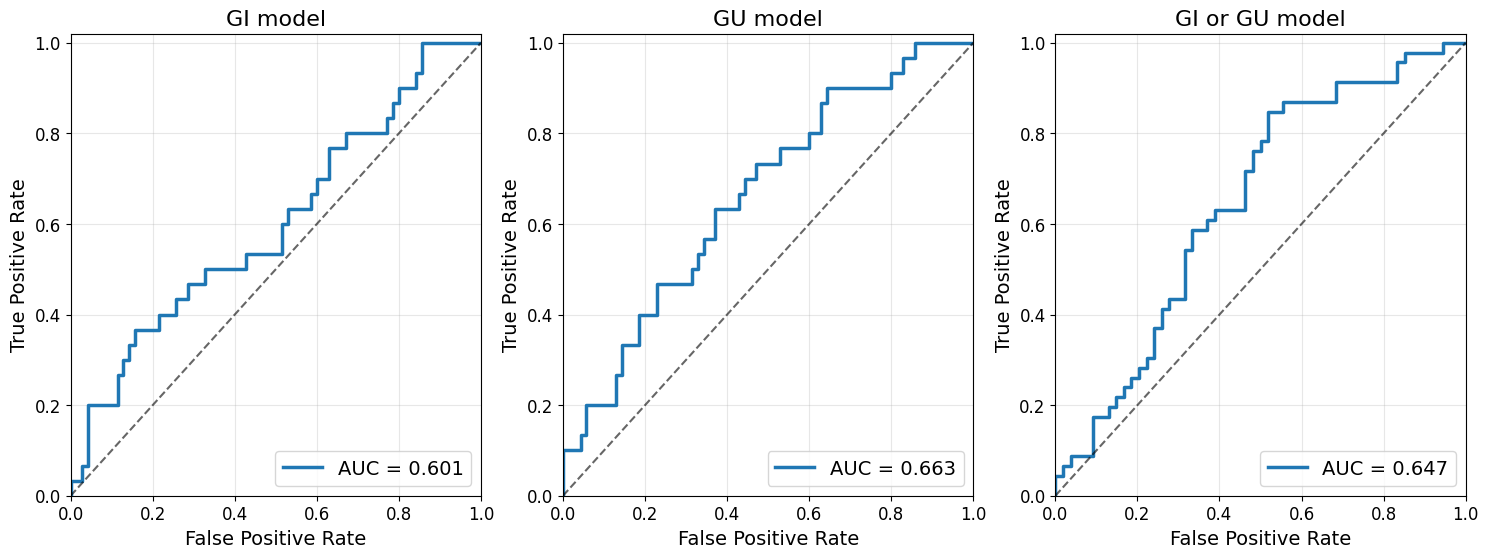

In [8]:
# Plot the classification performance of the combined model for each endpoint:
# urinary toxicity, intestinal toxicity, and the combined endpoint (U or I).

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()
auc_plot(data['outcome_I'], fit_res['predictions_I'], title=f'GI model', ax=axes[0])  # I endpoint
auc_plot(data['outcome_U'], fit_res['predictions_U'], title=f'GU model', ax=axes[1])  # U endpoint
auc_plot(data['outcome'], fit_res['predictions_overall'], title=f'GI or GU model', ax=axes[2]) # I or U endpoint (combined)
plt.show()

# Calibration

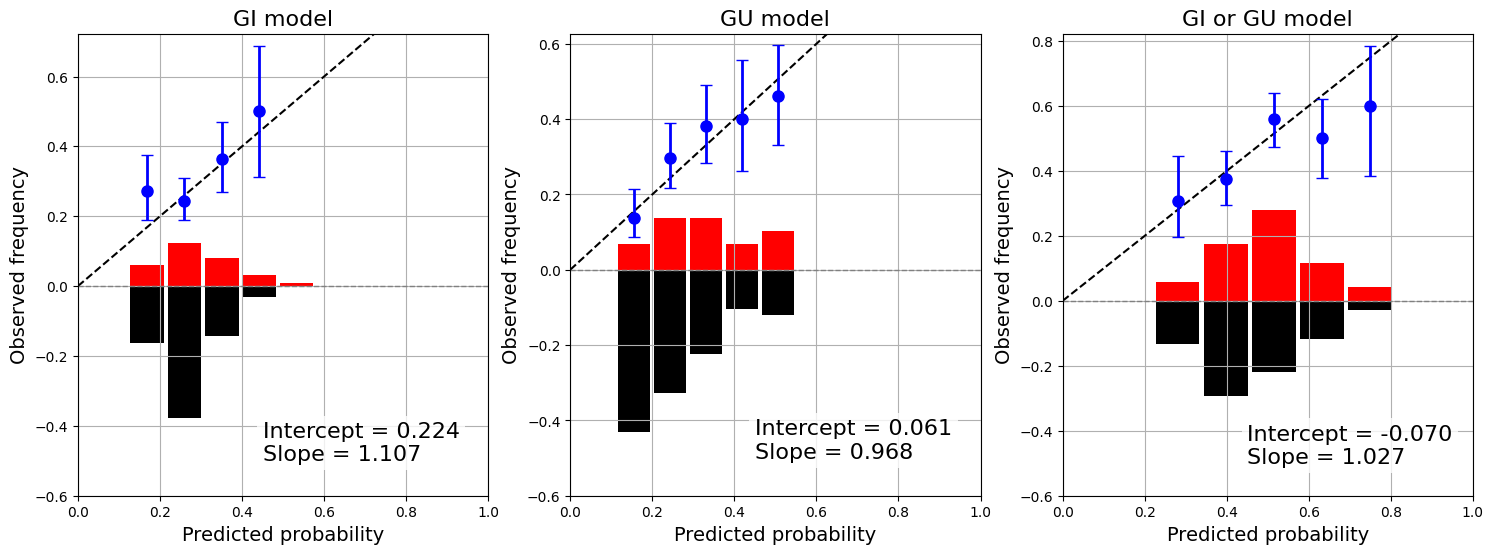

In [9]:
# Plot the calibration performance of the combined model for each endpoint:
# urinary toxicity, intestinal toxicity, and the combined endpoint (U or I).

n_bins = 5
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()
calibration_plot(data['outcome_I'], fit_res['predictions_I'], n_bins = n_bins, title=f'GI model', ax=axes[0])
calibration_plot(data['outcome_U'], fit_res['predictions_U'], n_bins = n_bins, title=f'GU model', ax=axes[1])
calibration_plot(data['outcome'], fit_res['predictions_overall'], n_bins = n_bins, title=f'GI or GU model', ax=axes[2])
plt.show()

# Bootstrap

In [11]:
# Estimate parameter uncertainty using constrained bootstrap resampling
bootstrap_res = fit_bootstrap(data, L1 = 0.05, L2 = 0.05, N_bootstraps = 500, coverage = 0.9)

Generating bootstrap samples...
Fitting bootstrap samples...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   35.9s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  5.4min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  9.6min
[Parallel(n_jobs=-1)]: Done 272 tasks      | elapsed: 18.7min
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed: 26.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 28.9min finished





Parameter                      Estimate [90% CI]
------------------------------------------------------------
beta_0_U                   -2.712 [-5.192, -1.873]
beta_EUDb                   0.011 [0.000, 0.042]
beta_EUDb_ATM               0.117 [0.063, 0.179]
beta_EUDb_PRS               0.235 [-0.032, 0.306]
beta_PRS_U                  0.409 [0.000, 2.910]
beta_0_PRS_U               -0.215 [-7.935, 10.324]
beta_0_I                   -4.435 [-6.224, -1.954]
beta_EUDr                   0.026 [0.001, 0.050]
beta_EUDr_ATM               0.054 [0.000, 0.108]
beta_EUDr_PRS               0.108 [-0.036, 0.316]
beta_PRS_I                  0.892 [0.000, 3.055]
beta_0_PRS_I                4.219 [-9.548, 8.327]
SNP_1(U)                   -0.379 [-1.301, 3.148]
SNP_2(U)                   -3.534 [-5.359, 3.491]
SNP_3(I)                    2.213 [-3.394, 3.631]
SNP_4(I)                   -1.500 [-2.639, 3.648]
NLL_UI_tot                124.873 [119.018, 126.465]
NLL_I                      59.078 [53